### Shift to Colab

In [2]:
# ── Install dependencies ────────────────────────────────────────────────────
!pip install -q transformers==5.0.0 datasets evaluate jiwer albumentations kaggle

# ── Mount Google Drive (persistent storage) ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Create persistent output dir on Drive
import os
DRIVE_DIR = "/content/drive/MyDrive/SmartStock"
os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(f"{DRIVE_DIR}/trocr-smart-stock-best", exist_ok=True)
print(f"Drive mounted. Output dir: {DRIVE_DIR}")

# ── Import Kaggle dataset ────────────────────────────────────────────────────
from google.colab import files

# Upload your kaggle.json API token (one-time per session)
# Get it from: kaggle.com → Account → API → Create New Token
files.upload()  # select kaggle.json when prompted

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download smart-stock-dataset from Kaggle
!kaggle datasets download -d maazahmad69/smart-stock-dataset -p /content/
!unzip -q /content/smart-stock-dataset.zip -d /content/smart-stock-dataset/
!rm /content/smart-stock-dataset.zip

# Verify contents
import os
for item in sorted(os.listdir("/content/smart-stock-dataset")):
    print(item)

Mounted at /content/drive
Drive mounted. Output dir: /content/drive/MyDrive/SmartStock


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/maazahmad69/smart-stock-dataset
License(s): unknown
100% 10.6G/10.6G [02:50<00:00, 66.8MB/s]

smart_stock_dataset_v2
trocr-smart-stock


#### **CORD's ground_truth** field is a raw JSON string. You must parse it and construct a flat text target from the menu array

In [3]:
import json
from collections import defaultdict
from PIL import Image

def extract_cord_crops(image: Image.Image, ground_truth_str: str) -> list:
    """
    Extract line-level crops from a CORD receipt image.

    Bounding boxes are in valid_line[].words[].quad, NOT in gt_parse.menu.
    Each group_id in valid_line = one logical receipt line.
    We group words by group_id, merge their quads into one bbox, crop it,
    and use the joined word texts as the OCR target.
    Only menu.* categories are kept (skip total, tax, header lines).

    Returns list of (cropped_PIL_image, text) pairs.
    """
    try:
        data = json.loads(ground_truth_str)
    except (json.JSONDecodeError, AttributeError):
        return []

    valid_lines = data.get("valid_line", [])
    if not valid_lines:
        return []

    # Group lines by group_id
    groups = defaultdict(list)
    for line in valid_lines:
        groups[line["group_id"]].append(line)

    w, h = image.size
    crops = []

    for gid, lines in groups.items():
        # Only keep menu lines (skip total, sub_total, etc.)
        if not any(l.get("category", "").startswith("menu.") for l in lines):
            continue

        all_words, all_xs, all_ys = [], [], []
        for line in lines:
            for word in line.get("words", []):
                text = word.get("text", "").strip()
                if text:
                    all_words.append(text)
                q = word.get("quad", {})
                if q:
                    all_xs += [q.get("x1",0), q.get("x2",0), q.get("x3",0), q.get("x4",0)]
                    all_ys += [q.get("y1",0), q.get("y2",0), q.get("y3",0), q.get("y4",0)]

        if not all_words or not all_xs:
            continue

        text = " ".join(all_words)
        x1, y1 = max(0, min(all_xs)), max(0, min(all_ys))
        x2, y2 = min(w, max(all_xs)), min(h, max(all_ys))
        if x2 <= x1 or y2 <= y1:
            continue

        crops.append((image.crop((x1, y1, x2, y2)), text))

    return crops

### **SROIE** Text Reconstruction
#### SROIE has bboxes per word. Group words by Y-coordinate (within 15px = same line), merge bounding boxes per line, crop each line region

In [4]:
def extract_sroie_crops(image: Image.Image, words: list, bboxes: list) -> list:
    """
    Group SROIE words into lines by Y-coordinate proximity.
    Each line bbox is cropped and paired with its joined text.
    Returns list of (cropped_PIL_image, text) pairs.
    """
    if not words or not bboxes:
        return []

    # Sort by top-Y of each word bbox
    items = sorted(zip(words, bboxes), key=lambda x: x[1][1])

    # Group into lines: words within 15px vertically = same line
    lines = []
    current_words, current_boxes = [items[0][0]], [items[0][1]]
    for word, box in items[1:]:
        if abs(box[1] - current_boxes[-1][1]) <= 15:
            current_words.append(word)
            current_boxes.append(box)
        else:
            lines.append((current_words, current_boxes))
            current_words, current_boxes = [word], [box]
    lines.append((current_words, current_boxes))

    w, h = image.size
    crops = []
    for line_words, line_boxes in lines:
        text = " ".join(line_words).strip()
        if not text:
            continue
        x1 = max(0, min(b[0] for b in line_boxes))
        y1 = max(0, min(b[1] for b in line_boxes))
        x2 = min(w, max(b[2] for b in line_boxes))
        y2 = min(h, max(b[3] for b in line_boxes))
        if x2 <= x1 or y2 <= y1:
            continue
        crops.append((image.crop((x1, y1, x2, y2)), text))
    return crops

### Combined Dataset Builder
OOM fix: Images encoded to PNG bytes immediately — no PIL accumulation in RAM.
Line crops: Each receipt yields multiple (crop, text) pairs instead of one (full_image, all_text).
SROIE 2x weighting: SROIE train concatenated twice — gives more weight to English receipt text vs CORD's Indonesian menus.
New dataset path: Since this is a rebuilt dataset, save to a new path to avoid loading the old full-image version.

In [5]:
import io
import json
from pathlib import Path
from datasets import load_dataset, Dataset, DatasetDict
from PIL import Image

# New path — line-crop dataset is incompatible with old full-image dataset
SAVE_PATH = Path("/content/smart-stock-dataset/smart_stock_dataset_v2")
if not SAVE_PATH.exists():
    SAVE_PATH = Path("/content/smart_stock_dataset_v2")  # fallback if rebuilding fresh

def pil_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="PNG")
    return buf.getvalue()

def iter_to_dataset(iterator) -> Dataset:
    """
    Convert an iterator of (PIL Image, text) tuples into a Dataset.
    Encodes each image to bytes immediately — never accumulates PIL objects in RAM.
    """
    img_bytes, texts = [], []
    for img, text in iterator:
        img_bytes.append(pil_to_bytes(img))
        texts.append(text)
    return Dataset.from_dict({"image_bytes": img_bytes, "text": texts})

def build_and_save_dataset():
    """
    Build line-crop CORD + SROIE dataset and save to disk.
    On subsequent runs, loads directly from disk — no reprocessing.
    """
    if SAVE_PATH.exists():
        print(f"Dataset found at {SAVE_PATH} — loading from disk...")
        return DatasetDict.load_from_disk(str(SAVE_PATH))

    print("Building line-crop dataset from scratch...")

    # --- CORD — line crops via bounding boxes ---
    print("Loading CORD...")
    cord = load_dataset("naver-clova-ix/cord-v2")

    def cord_iter(split):
        for ex in cord[split]:
            for crop, text in extract_cord_crops(ex["image"], ex["ground_truth"]):
                yield crop, text

    cord_train      = iter_to_dataset(cord_iter("train"))
    cord_validation = iter_to_dataset(cord_iter("validation"))
    cord_test       = iter_to_dataset(cord_iter("test"))
    print(f"  CORD train: {len(cord_train)} | val: {len(cord_validation)} | test: {len(cord_test)}")
    del cord

    # --- SROIE — line crops via word bbox grouping ---
    print("Loading SROIE...")
    sroie = load_dataset("sizhkhy/SROIE")

    def sroie_iter(split):
        for ex in sroie[split]:
            for crop, text in extract_sroie_crops(ex["images"], ex["words"], ex["bboxes"]):
                yield crop, text

    sroie_train = iter_to_dataset(sroie_iter("train"))
    sroie_test  = iter_to_dataset(sroie_iter("test"))
    print(f"  SROIE train: {len(sroie_train)} | test: {len(sroie_test)}")
    del sroie

    # --- Combine ---
    # SROIE train duplicated for 2x weight (more English receipt signal)
    # validation = CORD only (SROIE has no val split)
    from datasets import concatenate_datasets
    dataset_dict = DatasetDict({
        "train":      concatenate_datasets([cord_train, sroie_train, sroie_train]),
        "validation": cord_validation,
        "test":       concatenate_datasets([cord_test, sroie_test]),
    })

    # Save to Drive for persistence across sessions
    drive_save_path = Path("/content/drive/MyDrive/SmartStock/smart_stock_dataset_v2")
    drive_save_path.mkdir(parents=True, exist_ok=True)
    dataset_dict.save_to_disk(str(drive_save_path))
    # SAVE_PATH = drive_save_path  # update SAVE_PATH to Drive location

    print(f"\n✅ Saved to {SAVE_PATH}")
    print(f"   Train:      {len(dataset_dict['train'])}")
    print(f"   Validation: {len(dataset_dict['validation'])}")
    print(f"   Test:       {len(dataset_dict['test'])}")
    return dataset_dict

combined_dataset = build_and_save_dataset()

Dataset found at /content/smart-stock-dataset/smart_stock_dataset_v2 — loading from disk...


#### Expected sizes (line crops):

Train: ~24,000+ examples (CORD ~6k + SROIE ~9k × 2)
Validation: ~800 examples (CORD val crops)
Test: ~6,000 examples (CORD + SROIE test crops)

#### **Augmentation**
Apply augmentation only to training images, inline during the preprocess_trocr step. The augmentation simulates real-world receipt degradation.

In [6]:
import albumentations as A
import cv2
import numpy as np
from PIL import Image, ImageOps

receipt_augmentation = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=(-0.4, 0.15), p=0.6), # Stronger thermal fade
    A.GaussNoise(p=0.5),                                               # Scanner noise
    A.Rotate(limit=8, border_mode=cv2.BORDER_REPLICATE, p=0.5),        # Crumple tilt
    A.Perspective(scale=(0.02, 0.08), p=0.4),                          # Photo angle
    A.MotionBlur(blur_limit=5, p=0.3),                                 # Shaky photo
    A.ImageCompression(p=0.5),                                         # JPEG artifact
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),                          # Focus blur
    A.RandomShadow(p=0.2),                                             # Shadows on receipt
])

def apply_augmentation(pil_image: Image.Image) -> Image.Image:
    """Pad tiny line crops to min 32px height, then augment."""
    pil_image = pil_image.convert("RGB")
    if pil_image.height < 32:
        pad = 32 - pil_image.height
        pil_image = ImageOps.expand(pil_image, border=(0, pad//2, 0, pad - pad//2), fill=255)
    img_np = np.array(pil_image)
    augmented = receipt_augmentation(image=img_np)["image"]
    return Image.fromarray(augmented)

### Preprocessing Function

In [7]:
import io
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")

def preprocess_trocr(example, augment: bool = False):
    """
    Preprocess a single (image_bytes, text) example.
    Called per-item at access time — no upfront caching.

    Returns dict with 'pixel_values' (tensor) and 'labels' (tensor).
    """
    image = Image.open(io.BytesIO(example["image_bytes"])).convert("RGB")

    if augment:
        image = apply_augmentation(image)

    pixel_values = processor(images=image, return_tensors="pt").pixel_values

    labels = processor.tokenizer(
        example["text"],
        padding="max_length",
        max_length=128,
        truncation=True,
    ).input_ids

    labels = [
        t if t != processor.tokenizer.pad_token_id else -100
        for t in labels
    ]

    return {
        "pixel_values": pixel_values.squeeze(),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


class TrOCRDataset(TorchDataset):
    """
    On-the-fly preprocessing — processes each example at access time.
    Replaces .map() which caused either:
      - OOM (keep_in_memory=True on 31k examples)
      - OSError Errno 28 (cache_file_name on full disk)
    Zero disk usage, zero RAM accumulation, full dataset used.
    Compatible with Seq2SeqTrainer — accepts any PyTorch Dataset.
    """
    def __init__(self, hf_dataset, augment: bool = False):
        self.data    = hf_dataset
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return preprocess_trocr(self.data[idx], augment=self.augment)


train_dataset = TrOCRDataset(combined_dataset["train"],      augment=True)
val_dataset   = TrOCRDataset(combined_dataset["validation"], augment=False)
test_dataset  = TrOCRDataset(combined_dataset["test"],       augment=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Train: 31057 | Val: 221 | Test: 8301


### Model Setup

In [8]:
from transformers import VisionEncoderDecoderModel, GenerationConfig

# model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
model = VisionEncoderDecoderModel.from_pretrained(
    "/content/drive/MyDrive/SmartStock/trocr-smart-stock-best"
)

# /content/smart-stock-dataset/trocr-smart-stock/checkpoint-17478

# Required decoder config
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

# Generation config — must go on model.generation_config, not model.config
# max_new_tokens omitted here — set via generation_max_length in training_args
model.generation_config.eos_token_id         = processor.tokenizer.sep_token_id
model.generation_config.early_stopping       = True
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty       = 2.0
model.generation_config.num_beams            = 4

Loading weights:   0%|          | 0/480 [00:01<?, ?it/s]

### Training Arguments

In [9]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="/content/drive/MyDrive/SmartStock/trocr-smart-stock",

    # Training schedule
    num_train_epochs=10,              # reduced back to 10 -- larger dataset means more steps per epoch — more time to converge
    per_device_train_batch_size=8,    # Safe for Kaggle T4 (16GB VRAM)
    per_device_eval_batch_size=8,

    # Optimizer
    learning_rate=2e-5,               # reduced from 5e-5 — more stable fine-tuning
    warmup_ratio=0.06,                # replaces warmup_steps=500 (was 56% of training — way too long)
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,                # clips exploding gradients — fixes high grad_norm seen in run 1

    # Eval & saving
    eval_strategy="epoch",            # renamed from evaluation_strategy in transformers 4.46+
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,          # Lower CER = better
    save_total_limit=5,               # keep 5 checkpoints — prevents losing progress if session times out

    # Generation — only set max_new_tokens, not max_length (conflict warning)
    predict_with_generate=True,
    generation_max_length=128,

    # Performance
    fp16=True,                        # Mixed precision — required on T4
    dataloader_num_workers=2,

    # Logging — log every epoch so CER/WER appear in the table
    logging_dir="./logs",
    logging_steps=50,
    log_level="info",
    report_to="none",                 # Disable wandb on Kaggle
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Metrics

In [10]:
!pip install jiwer

In [11]:
import numpy as np
from jiwer import cer, wer

def compute_metrics(pred):
    pred_ids   = pred.predictions
    labels_ids = pred.label_ids

    # pred_ids may be float logits — argmax to get token ids
    if pred_ids.dtype != np.int64 and pred_ids.ndim == 3:
        pred_ids = np.argmax(pred_ids, axis=-1)

    # Clip to valid vocab range to prevent OverflowError during decode
    vocab_size = processor.tokenizer.vocab_size
    pred_ids   = np.clip(pred_ids, 0, vocab_size - 1)

    # Decode predictions
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)

    # Replace -100 (padding mask) with pad token id before decoding
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    return {
        "cer": round(cer(label_str, pred_str), 4),
        "wer": round(wer(label_str, pred_str), 4),
    }

### Trainer and Training

In [13]:
import torch
from transformers import Seq2SeqTrainer

def collate_fn(batch):
    """
    Custom collator for TrOCR.
    pixel_values and labels are tensors returned directly by TrOCRDataset.__getitem__.
    torch.stack combines them into batches.
    """
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels       = torch.stack([item["labels"]       for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

# Resume from checkpoint — checks Kaggle input dataset first, then local working dir
# Checkpoints saved inside smart-stock-dataset (same dataset as the line-crop dataset)
# CHECKPOINT_INPUT = Path("/kaggle/input/datasets/maazahmad69/smart-stock-dataset/trocr-smart-stock")
CHECKPOINT_INPUT = Path("/content/drive/MyDrive/SmartStock/trocr-smart-stock-best")

checkpoint_dir   = CHECKPOINT_INPUT if CHECKPOINT_INPUT.exists() else Path("./trocr-smart-stock")

checkpoints = sorted(checkpoint_dir.glob("checkpoint-*")) if checkpoint_dir.exists() else []
# resume_from = str(checkpoints[-1]) if checkpoints else None

# resume_from = "/content/smart-stock-dataset/trocr-smart-stock/checkpoint-17478"
resume_from = "/content/drive/MyDrive/SmartStock/trocr-smart-stock/checkpoint-19420"

if resume_from:
    print(f"Resuming from: {resume_from}")
else:
    print("No checkpoint found — training from scratch")

trainer.train(resume_from_checkpoint=resume_from)

Loading model from /content/drive/MyDrive/SmartStock/trocr-smart-stock/checkpoint-19420.


Resuming from: /content/drive/MyDrive/SmartStock/trocr-smart-stock/checkpoint-19420


There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].
***** Running training *****
  Num examples = 31,057
  Num Epochs = 10
  Instantaneous batch size per device = 8
  Training with DataParallel so batch size has been adjusted to: 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 19,420
  Number of trainable parameters = 333,921,792
	per_device_train_batch_size: 8 (from args) != 16 (from trainer_state.json)
  Continuing training from checkpoint, will skip to saved global_step
  Continuing training from epoch 10
  Continuing training from global step 19420
  Will skip the first 10 epochs then the first 0 batches in the first epoch.


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from ./trocr-smart-stock/checkpoint-15536 (score: 0.133).
Could not locate the best model at ./trocr-smart-stock/checkpoint-155

Epoch,Training Loss,Validation Loss


TrainOutput(global_step=19420, training_loss=0.0, metrics={'train_runtime': 0.0404, 'train_samples_per_second': 7689140.571, 'train_steps_per_second': 480803.393, 'total_flos': 2.3239493176761778e+20, 'train_loss': 0.0, 'epoch': 10.0})

### Training Curves

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

print(history.columns)
history.head()

Index(['epoch', 'grad_norm', 'learning_rate', 'loss', 'step', 'eval_cer',
       'eval_loss', 'eval_runtime', 'eval_samples_per_second',
       'eval_steps_per_second', 'eval_wer', 'train_runtime',
       'train_samples_per_second', 'train_steps_per_second', 'total_flos',
       'train_loss'],
      dtype='object')


,epoch,grad_norm,learning_rate,loss,step,eval_cer,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_wer,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.025747,46.461933,8.404803e-07,15.671593,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.051493,35.329800,1.698113e-06,12.237158,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.077240,24.107512,2.555746e-06,10.052162,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.102987,29.201387,3.413379e-06,9.376604,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.128733,22.417814,4.271012e-06,8.669158,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


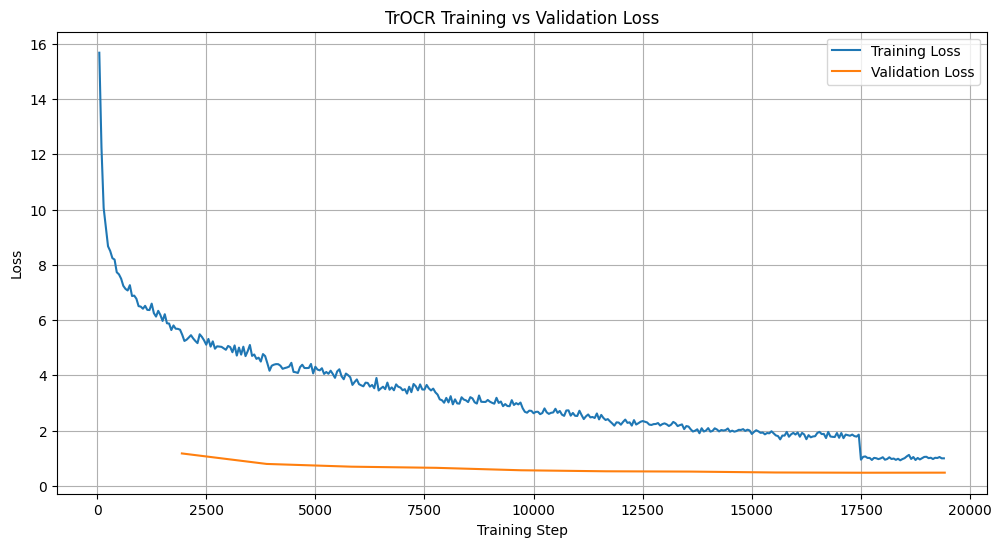

In [15]:
train_logs = history[history["loss"].notna()]
eval_logs  = history[history["eval_loss"].notna()]

plt.figure(figsize=(12,6))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    label="Training Loss"
)

plt.plot(
    eval_logs["step"],
    eval_logs["eval_loss"],
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("TrOCR Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

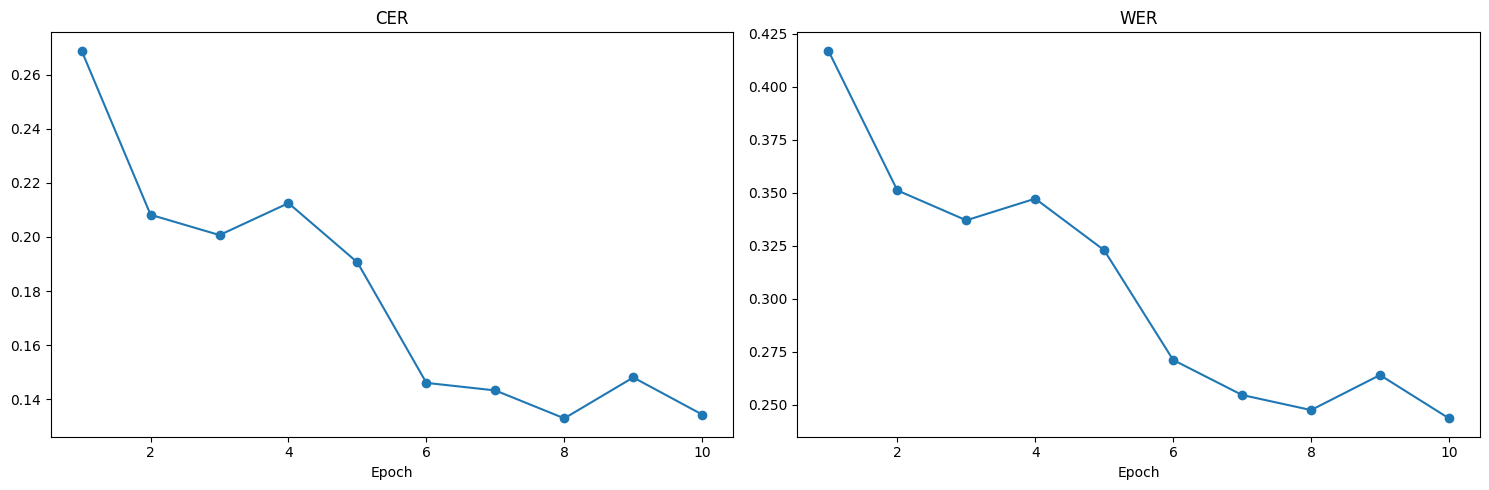

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

axes[0].plot(eval_logs["epoch"], eval_logs["eval_cer"], marker="o")
axes[0].set_title("CER")
axes[0].set_xlabel("Epoch")

axes[1].plot(eval_logs["epoch"], eval_logs["eval_wer"], marker="o")
axes[1].set_title("WER")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [17]:
summary = eval_logs[
    ["epoch", "eval_loss", "eval_cer", "eval_wer"]
]

summary

,epoch,eval_loss,eval_cer,eval_wer
38,1.0,1.175672,0.2688,0.4169
78,2.0,0.795878,0.2082,0.3511
118,3.0,0.696738,0.2007,0.3370
158,4.0,0.655258,0.2125,0.3472
198,5.0,0.567077,0.1906,0.3229
238,6.0,0.530030,0.1461,0.2712
277,7.0,0.519313,0.1433,0.2547
317,8.0,0.486715,0.1330,0.2476
357,9.0,0.478171,0.1481,0.2641
397,10.0,0.480487,0.1344,0.2437


### Save & Export

In [18]:
from pathlib import Path

# Save to both Drive (persistent) and local /content/ (for this session)
DRIVE_SAVE = "/content/drive/MyDrive/SmartStock/trocr-smart-stock-best"
LOCAL_SAVE = "/content/trocr-smart-stock-best"

for save_path in [DRIVE_SAVE, LOCAL_SAVE]:
    trainer.save_model(save_path)
    processor.save_pretrained(save_path)
    model.generation_config.save_pretrained(save_path)
    print(f"Saved to: {save_path}")

# Verify Drive copy
expected_files = [
    "model.safetensors", "config.json", "generation_config.json",
    "tokenizer_config.json", "tokenizer.json", "processor_config.json",
]
print(f"\nDrive save verification ({DRIVE_SAVE}):")
for fname in expected_files:
    fpath = Path(DRIVE_SAVE) / fname
    exists = fpath.exists()
    size = fpath.stat().st_size / 1e6 if exists else 0
    print(f"  {'✅' if exists else '❌'} {fname} ({size:.1f} MB)")

Saving model checkpoint to /content/drive/MyDrive/SmartStock/trocr-smart-stock-best
Configuration saved in /content/drive/MyDrive/SmartStock/trocr-smart-stock-best/config.json
Configuration saved in /content/drive/MyDrive/SmartStock/trocr-smart-stock-best/generation_config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/SmartStock/trocr-smart-stock-best/model.safetensors
tokenizer config file saved in /content/drive/MyDrive/SmartStock/trocr-smart-stock-best/tokenizer_config.json
processor saved in /content/drive/MyDrive/SmartStock/trocr-smart-stock-best/processor_config.json
Configuration saved in /content/drive/MyDrive/SmartStock/trocr-smart-stock-best/generation_config.json
Saving model checkpoint to /content/trocr-smart-stock-best
Configuration saved in /content/trocr-smart-stock-best/config.json
Configuration saved in /content/trocr-smart-stock-best/generation_config.json


Saved to: /content/drive/MyDrive/SmartStock/trocr-smart-stock-best


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/trocr-smart-stock-best/model.safetensors
tokenizer config file saved in /content/trocr-smart-stock-best/tokenizer_config.json
processor saved in /content/trocr-smart-stock-best/processor_config.json
Configuration saved in /content/trocr-smart-stock-best/generation_config.json


Saved to: /content/trocr-smart-stock-best

Drive save verification (/content/drive/MyDrive/SmartStock/trocr-smart-stock-best):
  ✅ model.safetensors (1335.7 MB)
  ✅ config.json (0.0 MB)
  ✅ generation_config.json (0.0 MB)
  ✅ tokenizer_config.json (0.0 MB)
  ✅ tokenizer.json (3.6 MB)
  ✅ processor_config.json (0.0 MB)


### Evaluate on Test Set

In [ ]:
# results = trainer.evaluate(test_dataset)
# print(f"Test CER: {results['eval_cer']:.4f}")
# print(f"Test WER: {results['eval_wer']:.4f}")

# # Target benchmarks:
# # CER ≤ 0.05 (5%)
# # WER ≤ 0.10 (10%)

### Qualitative Evaluation

In [ ]:
# sample = combined_dataset["test"][0]

# image = sample["image"]

# pixel_values = processor(
#     image,
#     return_tensors="pt"
# ).pixel_values.to(model.device)

# generated_ids = model.generate(pixel_values)

# prediction = processor.batch_decode(
#     generated_ids,
#     skip_special_tokens=True
# )[0]

# print("GROUND TRUTH:\n")
# print(sample["text"])

# print("\n")
# print("="*80)

# print("\nPREDICTION:\n")
# print(prediction)

# image

### Hyperparameter Search with **Optuna**
After the first clean training run with line crops, use Optuna (Bayesian optimization) via HuggingFace built-in hyperparameter_search to find optimal values.

In [19]:
!pip install optuna -q

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True,),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.03, 0.15,),
    }

def model_init():
    m = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
    m.config.decoder_start_token_id = processor.tokenizer.cls_token_id
    m.config.pad_token_id           = processor.tokenizer.pad_token_id
    m.config.vocab_size             = m.config.decoder.vocab_size
    m.generation_config.eos_token_id         = processor.tokenizer.sep_token_id
    m.generation_config.early_stopping       = True
    m.generation_config.no_repeat_ngram_size = 3
    m.generation_config.length_penalty       = 2.0
    m.generation_config.num_beams            = 4
    return m

# Use HF dataset (combined_dataset) not TorchDataset for .select()
# TrOCRDataset is a PyTorch Dataset — it has no .select() method
# Search args — disable predict_with_generate for speed (eval loss only, no generation)
import copy

search_args = copy.deepcopy(training_args)

# search_args.predict_with_generate = False
# search_args.num_train_epochs = 5  # full epochs on subset
# search_args.dataloader_num_workers = 0  # safer for sleep / resume

search_args.num_train_epochs = 6
search_args.predict_with_generate = True
search_args.eval_accumulation_steps = 4
search_args.dataloader_num_workers = 0

# Use HF dataset .select() then wrap in TrOCRDataset
# TrOCRDataset has no .select() — must use combined_dataset (HF dataset) directly

# smaller validation for Optuna
search_val_hf = combined_dataset["validation"].select(range(min(500, len(combined_dataset["validation"]))))
search_val = TrOCRDataset(search_val_hf, augment=False)

# 20% train subset
search_hf = combined_dataset["train"].select(range(len(combined_dataset["train"]) // 4))
search_train = TrOCRDataset(search_hf, augment=True)

search_trainer = Seq2SeqTrainer(
    model_init=model_init,
    args=search_args,
    train_dataset=search_train,
    eval_dataset=search_val,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

best_run = search_trainer.hyperparameter_search(
    direction="minimize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=6,
)

print("Best hyperparameters:", best_run.hyperparameters)
# Apply to training_args for final full training run
for k, v in best_run.hyperparameters.items():
    setattr(training_args, k, v)
# Re-enable generation for final training
training_args.predict_with_generate = True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.8 MB/s eta 0:00:00


loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--microsoft--trocr-base-printed/snapshots/93450be3f1ed40a930690d951ef3932687cc1892/config.json
Model config VisionEncoderDecoderConfig {
  "architectures": [
    "VisionEncoderDecoderModel"
  ],
  "decoder": {
    "_name_or_path": "",
    "activation_dropout": 0.0,
    "activation_function": "gelu",
    "add_cross_attention": true,
    "architectures": null,
    "attention_dropout": 0.0,
    "bos_token_id": 0,
    "chunk_size_feed_forward": 0,
    "classifier_dropout": 0.0,
    "cross_attention_hidden_size": 768,
    "d_model": 1024,
    "decoder_attention_heads": 16,
    "decoder_ffn_dim": 4096,
    "decoder_layerdrop": 0.0,
    "decoder_layers": 12,
    "decoder_start_token_id": 2,
    "dropout": 0.1,
    "dtype": null,
    "eos_token_id": 2,
    "finetuning_task": null,
    "id2label": {
      "0": "LABEL_0",
      "1": "LABEL_1"
    },
    "init_std": 0.02,
    "is_decoder": true,
    "is_encode

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--microsoft--trocr-base-printed/snapshots/93450be3f1ed40a930690d951ef3932687cc1892/model.safetensors
Will use dtype=torch.float32 as defined in model's config object
Generate config GenerationConfig {
  "output_attentions": false,
  "output_hidden_states": false
}

Generate config GenerationConfig {
  "bos_token_id": 0,
  "decoder_start_token_id": 2,
  "eos_token_id": 2,
  "output_attentions": false,
  "output_hidden_states": false,
  "pad_token_id": 1,
  "use_cache": false
}



Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
loading configuration file generation_config.json from cache at /root/.cache/huggingface/hub/models--microsoft--trocr-base-printed/snapshots/93450be3f1ed40a930690d951ef3932687cc1892/generation_config.json
Generate config GenerationConfig {
  "bos_token_id": 0,
  "decoder_start_token_id": 2,
  "eos_token_id": 2,
  "pad_token_id": 1,
  "use_cache": false
}

***** Running training *****
  Num examples = 6,211
  Num Epochs = 5
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 3,885
  Number of trainab

Epoch,Training Loss,Validation Loss


[W 2026-06-12 10:01:12,535] Trial 1 failed with parameters: {'learning_rate': 2.2489717146453076e-05, 'warmup_ratio': 0.043616460649543796} because of the following error: OutOfMemoryError('CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 17.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.09 GiB is allocated by PyTorch, and 317.67 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/usr/local/lib

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 17.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.09 GiB is allocated by PyTorch, and 317.67 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)